In [39]:
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import os
import torchvision.transforms as transforms
from timm import create_model

class MicrogliaDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        # Load the CSV with filenames and scores
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

        # Sanity check for expected columns
        if "filename" not in self.data.columns or "score" not in self.data.columns:
            raise ValueError("CSV must contain 'filename' and 'score' columns.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Grab row
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row["filename"] + '.png')

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Apply transform if any
        if self.transform:
            image = self.transform(image)

        # Return image + score
        return image, float(row["score"]), row["filename"] + '.png'

In [36]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])


val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])


import torch.nn as nn
from torchvision import models

def build_model():
    model = create_model(
    'convnext_tiny',
    pretrained=True,
    num_classes=1,   # regression output
    )

    return model

train_ds = MicrogliaDataset(
    img_dir="C:\\Users\\Ben\\Box\\duke_bilbo\\MemberFolders\\Ben\\statistical_learning\\datascience_projects\\microglia_ramification\\dataset\\train\\images",
    csv_path="C:\\Users\\Ben\\Box\\duke_bilbo\\MemberFolders\\Ben\\statistical_learning\\datascience_projects\\microglia_ramification\\dataset\\train\\train.csv",
    transform=train_tf
)

val_ds = MicrogliaDataset(
    img_dir="C:\\Users\\Ben\\Box\\duke_bilbo\\MemberFolders\\Ben\\statistical_learning\\datascience_projects\\microglia_ramification\\dataset\\val\\images",
    csv_path="C:\\Users\\Ben\\Box\\duke_bilbo\\MemberFolders\\Ben\\statistical_learning\\datascience_projects\\microglia_ramification\\dataset\\val\\val.csv",
    transform=val_tf
)

In [3]:
os.chdir('C:\\Users\\ben\\Box\\duke_bilbo\\MemberFolders\\Ben\\statistical_learning\\datascience_projects\\microglia_ramification\\dataset\\')

In [41]:
train_ds = MicrogliaDataset(
    img_dir="outliers_removed\\train\\imgs",
    csv_path="outliers_removed\\train\\train.csv",
    transform=train_tf
)

val_ds = MicrogliaDataset(
    img_dir="outliers_removed\\val\\imgs",
    csv_path="outliers_removed\\val\\val.csv",
    transform=val_tf
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)

In [7]:
import torch
from torch.utils.data import DataLoader

model = build_model().cuda()
epochs = 50

criterion = nn.L1Loss()  # MAE is often better for morphology
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)



for epoch in range(epochs):
    model.train()
    train_loss = 0
    for imgs, scores in train_loader:
        imgs, scores = imgs.cuda(), scores.unsqueeze(1).cuda()

        pred = model(imgs)
        loss = criterion(pred, scores)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
    
    print(f"Epoch {epoch} | Train MAE: {train_loss/len(train_loader):.3f}")

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, scores in val_loader:
            imgs, scores = imgs.cuda(), scores.unsqueeze(1).cuda()
            pred = model(imgs)
            loss = criterion(pred, scores)
            val_loss += loss.item()

    print(f"   Val MAE: {val_loss/len(val_loader):.3f}")

Epoch 0 | Train MAE: 0.839
   Val MAE: 0.687
Epoch 1 | Train MAE: 0.639
   Val MAE: 0.624
Epoch 2 | Train MAE: 0.589
   Val MAE: 0.587
Epoch 3 | Train MAE: 0.446
   Val MAE: 0.572
Epoch 4 | Train MAE: 0.533
   Val MAE: 1.101
Epoch 5 | Train MAE: 0.571
   Val MAE: 0.514
Epoch 6 | Train MAE: 0.444
   Val MAE: 0.544
Epoch 7 | Train MAE: 0.460
   Val MAE: 0.603
Epoch 8 | Train MAE: 0.386
   Val MAE: 0.661
Epoch 9 | Train MAE: 0.428
   Val MAE: 0.742
Epoch 10 | Train MAE: 0.369
   Val MAE: 0.551
Epoch 11 | Train MAE: 0.424
   Val MAE: 0.603
Epoch 12 | Train MAE: 0.458
   Val MAE: 0.555
Epoch 13 | Train MAE: 0.375
   Val MAE: 0.656
Epoch 14 | Train MAE: 0.409
   Val MAE: 0.706
Epoch 15 | Train MAE: 0.331
   Val MAE: 0.574
Epoch 16 | Train MAE: 0.361
   Val MAE: 0.701
Epoch 17 | Train MAE: 0.359
   Val MAE: 0.517
Epoch 18 | Train MAE: 0.335
   Val MAE: 0.676
Epoch 19 | Train MAE: 0.359
   Val MAE: 0.466
Epoch 20 | Train MAE: 0.307
   Val MAE: 0.539
Epoch 21 | Train MAE: 0.340
   Val MAE: 0.55

In [8]:
torch.save(model, "microglia_cnn_nooutliers_convnext_d11.pth")

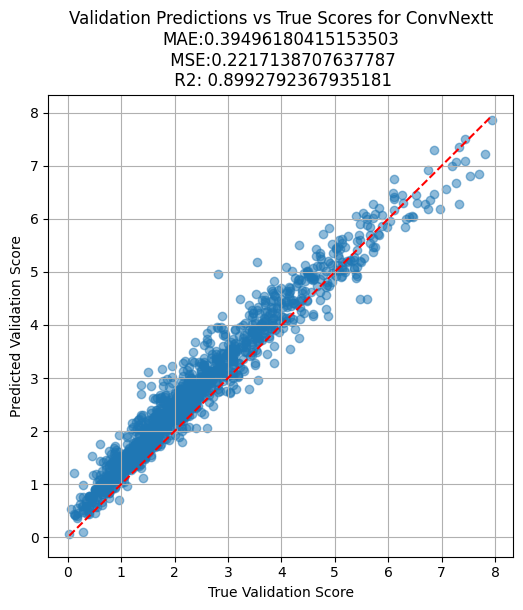

In [42]:
model.eval()
val_preds = []
val_trues = []
image_name = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
with torch.no_grad():
    for imgs, scores, fnames in train_loader:   # <-- your validation dataloader
        imgs = imgs.to(device)
        image_name.extend(fnames)
        scores = scores.to(device).float()

        outputs = model(imgs).squeeze()

        val_preds.extend(outputs.cpu().numpy())
        val_trues.extend(scores.cpu().numpy())

import numpy as np
val_preds = np.array(val_preds)
val_trues = np.array(val_trues)
mae = mean_absolute_error(val_trues, val_preds)
mse = mean_squared_error(val_trues, val_preds)
r2 = r2_score(val_trues, val_preds)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(val_trues, val_preds, alpha=0.5)

# identity line
min_val = min(val_trues.min(), val_preds.min())
max_val = max(val_trues.max(), val_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Validation Score")
plt.ylabel("Predicted Validation Score")
plt.title("Validation Predictions vs True Scores for ConvNextt\nMAE:" 
          + str(mae) 
          + '\n MSE:' 
          + str(mse) 
          + '\n R2: ' 
          + str(r2)
         )
plt.grid(True)
plt.show()

In [43]:
test_df = pd.DataFrame(val_trues, image_name).rename(columns = {0:'val_trues'})
test_df['val_preds'] = val_preds
test_df.to_csv('test_dataset_preds_jan7.csv')

In [22]:
julia_ds = MicrogliaDataset(
    img_dir="julias_images\\imgs",
    csv_path="julias_images\\julias_images_AUC_normalized.csv",
    transform=train_tf
)

julia_loader = DataLoader(julia_ds, batch_size=32)

(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(32,)
(20,)


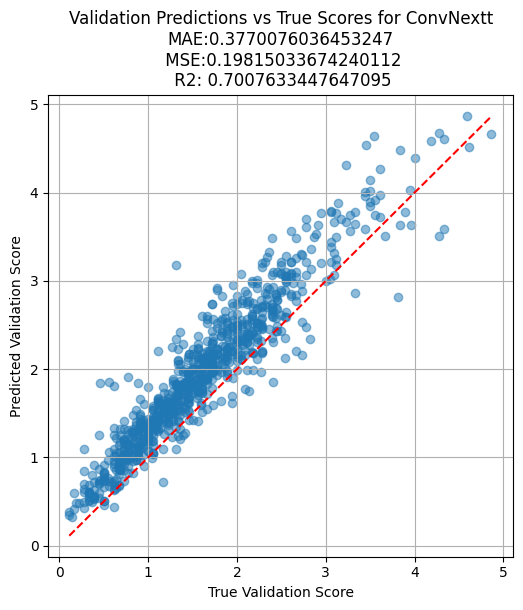

In [26]:
model.eval()
image_name = []
val_preds = []
val_trues = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
with torch.no_grad():
    for imgs, scores, fnames in julia_loader:   # <-- your validation dataloader
        imgs = imgs.to(device)
        image_name.extend(fnames)
        scores = scores.to(device).float()

        outputs = model(imgs).squeeze()

        val_preds.extend(outputs.cpu().numpy())
        val_trues.extend(scores.cpu().numpy())

import numpy as np
val_preds = np.array(val_preds)
val_trues = np.array(val_trues)
mae = mean_absolute_error(val_trues, val_preds)
mse = mean_squared_error(val_trues, val_preds)
r2 = r2_score(val_trues, val_preds)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(val_trues, val_preds, alpha=0.5)

# identity line
min_val = min(val_trues.min(), val_preds.min())
max_val = max(val_trues.max(), val_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("True Validation Score")
plt.ylabel("Predicted Validation Score")
plt.title("Validation Predictions vs True Scores for ConvNextt\nMAE:" 
          + str(mae) 
          + '\n MSE:' 
          + str(mse) 
          + '\n R2: ' 
          + str(r2)
         )
plt.grid(True)
plt.show()

In [32]:
julia_df = pd.DataFrame(val_trues, image_name).rename(columns = {0:'val_trues'})
julia_df['val_preds'] = val_preds
julia_df.to_csv('julia_images_preds_jan7.csv')